# 🛠️ Preparación de los Datos

In [2]:
import pandas as pd

df = pd.read_csv("TelecomX_datos_limpios.csv")

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas: 7043
Columnas: 21


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [3]:
# 1. Eliminar columna customerID que no aporta valor al análisis
df = df.drop(columns=["customerID"])

print("Columnas después de eliminar customerID:")
print(df.columns.tolist())
print(f"\nFilas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Columnas después de eliminar customerID:
['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']

Filas: 7043
Columnas: 20


In [4]:
# 2. Convertir variables categóricas a formato numérico
df = pd.get_dummies(df, drop_first=True)

print("Columnas después del encoding:")
print(df.columns.tolist())
print(f"\nFilas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head()

Columnas después del encoding:
['SeniorCitizen', 'tenure', 'Charges.Monthly', 'Charges.Total', 'Churn_Yes', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Filas: 7043
Columnas: 31


,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Churn_Yes,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,65.6,593.30,False,False,True,True,True,False,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,False,True,False,False,True,False,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,True,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,True,True,True,False,True,False,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,True,False,True,False,True,False,...,False,True,False,False,False,False,True,False,False,True


In [5]:
# 3. Proporción de clientes que cancelaron vs permanecieron
proporcion = df["Churn_Yes"].value_counts(normalize=True) * 100

print("=== PROPORCIÓN DE CHURN ===")
print(f"Clientes que permanecieron: {proporcion[False]:.1f}%")
print(f"Clientes que cancelaron: {proporcion[True]:.1f}%")

=== PROPORCIÓN DE CHURN ===
Clientes que permanecieron: 73.5%
Clientes que cancelaron: 26.5%


In [6]:
from sklearn.preprocessing import StandardScaler

# Columnas numéricas a normalizar
columnas_numericas = ["tenure", "Charges.Monthly", "Charges.Total"]

scaler = StandardScaler()
df[columnas_numericas] = scaler.fit_transform(df[columnas_numericas])

print("=== DATOS NORMALIZADOS ===")
print(df[columnas_numericas].describe().round(2))

=== DATOS NORMALIZADOS ===
        tenure  Charges.Monthly  Charges.Total
count  7043.00          7043.00        7032.00
mean     -0.00            -0.00           0.00
std       1.00             1.00           1.00
min      -1.32            -1.55          -1.00
25%      -0.95            -0.97          -0.83
50%      -0.14             0.19          -0.39
75%       0.92             0.83           0.67
max       1.61             1.79           2.82


# 🎯 Correlación y Selección de Variables

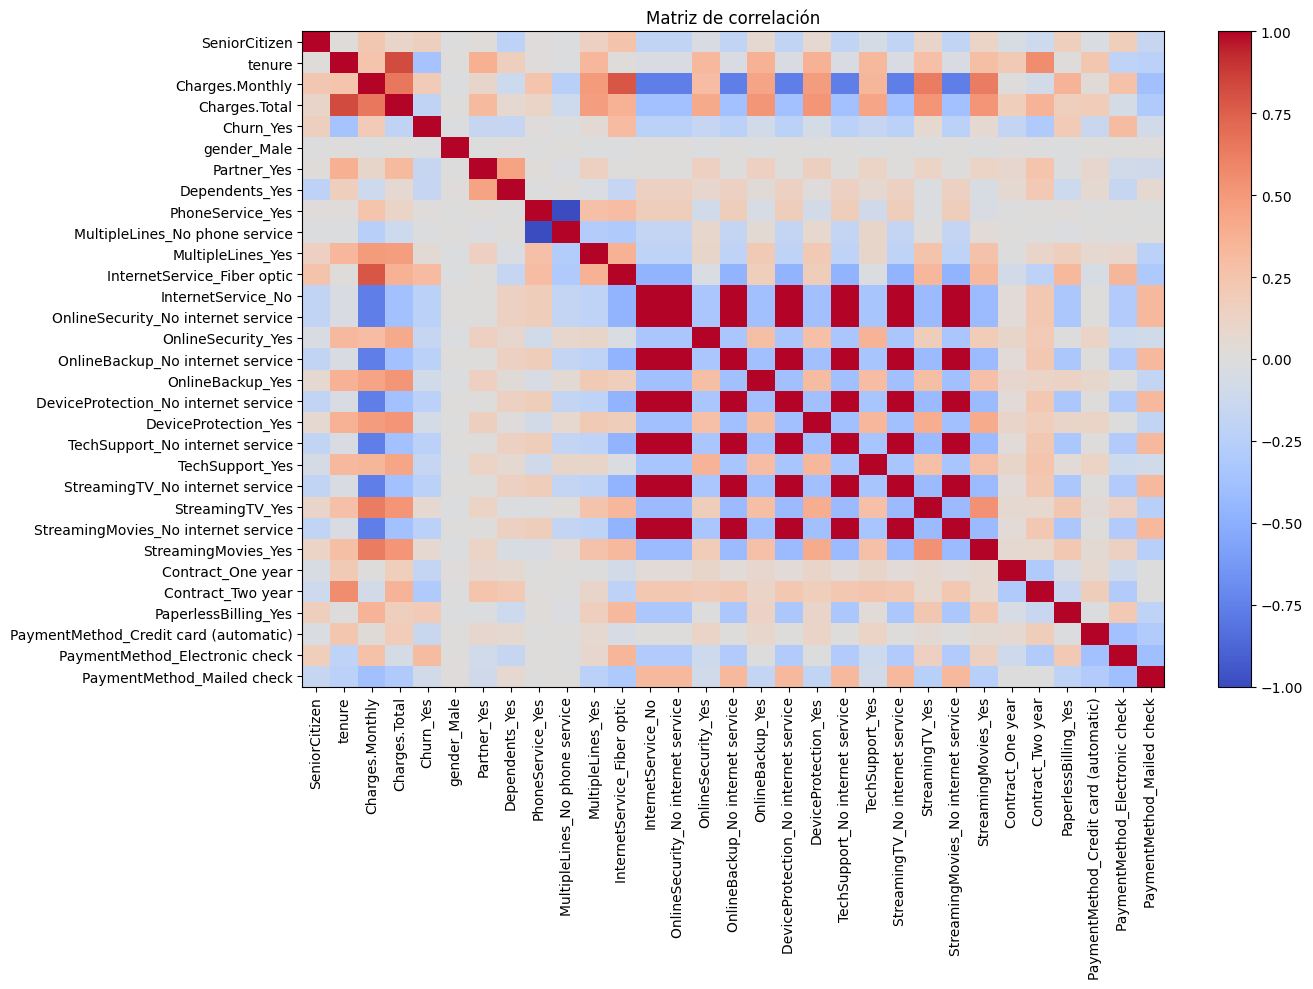

=== CORRELACIÓN CON CHURN ===
Churn_Yes                                1.00
InternetService_Fiber optic              0.31
PaymentMethod_Electronic check           0.30
Charges.Monthly                          0.19
PaperlessBilling_Yes                     0.19
SeniorCitizen                            0.15
StreamingTV_Yes                          0.06
StreamingMovies_Yes                      0.06
MultipleLines_Yes                        0.04
PhoneService_Yes                         0.01
gender_Male                             -0.01
MultipleLines_No phone service          -0.01
DeviceProtection_Yes                    -0.07
OnlineBackup_Yes                        -0.08
PaymentMethod_Mailed check              -0.09
PaymentMethod_Credit card (automatic)   -0.13
Partner_Yes                             -0.15
Dependents_Yes                          -0.16
TechSupport_Yes                         -0.16
OnlineSecurity_Yes                      -0.17
Contract_One year                       -0.18
Char

In [7]:
import matplotlib.pyplot as plt

# Matriz de correlación
correlacion = df.corr()

plt.figure(figsize=(14, 10))
plt.imshow(correlacion, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(correlacion.columns)), correlacion.columns, rotation=90)
plt.yticks(range(len(correlacion.columns)), correlacion.columns)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

# Correlación específica con Churn
print("=== CORRELACIÓN CON CHURN ===")
print(correlacion["Churn_Yes"].sort_values(ascending=False).round(2))

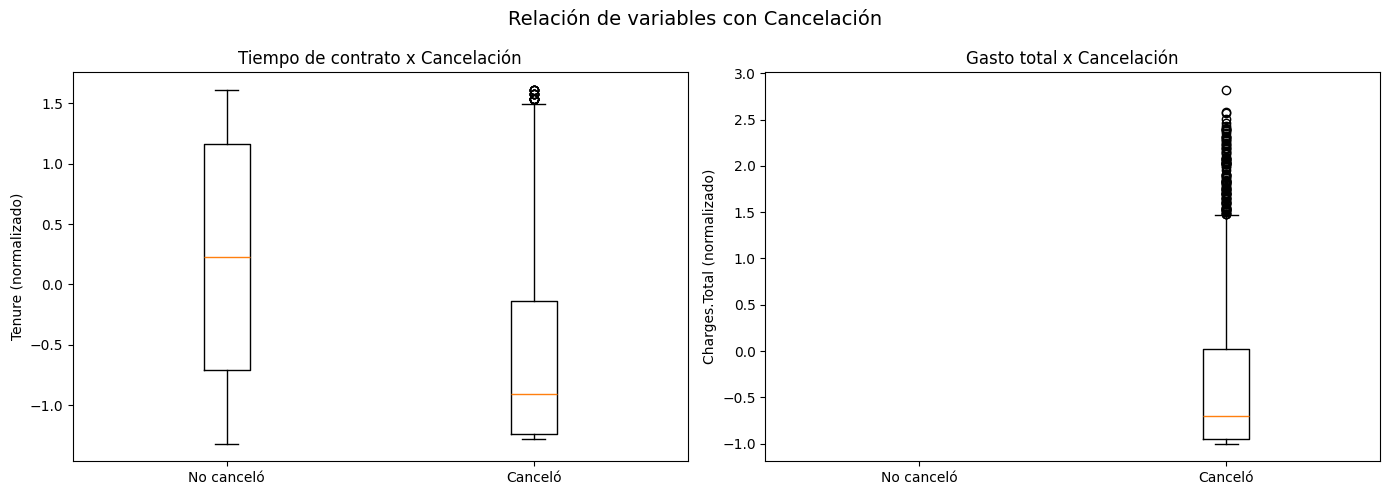

In [10]:
# Tiempo de contrato x Cancelación y Gasto total x Cancelación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: tenure x Churn
churn_no = df[df["Churn_Yes"] == False]["tenure"]
churn_yes = df[df["Churn_Yes"] == True]["tenure"]

axes[0].boxplot([churn_no, churn_yes], tick_labels=["No canceló", "Canceló"])
axes[0].set_title("Tiempo de contrato x Cancelación")
axes[0].set_ylabel("Tenure (normalizado)")

# Boxplot: Charges.Total x Churn
total_no = df[df["Churn_Yes"] == False]["Charges.Total"]
total_yes = df[df["Churn_Yes"] == True]["Charges.Total"]

axes[1].boxplot([total_no, total_yes], tick_labels=["No canceló", "Canceló"])
axes[1].set_title("Gasto total x Cancelación")
axes[1].set_ylabel("Charges.Total (normalizado)")

plt.suptitle("Relación de variables con Cancelación", fontsize=14)
plt.tight_layout()
plt.show()

# 🤖 Modelado Predictivo

In [11]:
from sklearn.model_selection import train_test_split

# Separamos variables predictoras (X) y variable objetivo (y)
X = df.drop(columns=["Churn_Yes"])
y = df["Churn_Yes"]

# Dividimos en 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("=== DIVISIÓN DEL DATASET ===")
print(f"Total de datos: {df.shape[0]}")
print(f"Entrenamiento: {X_train.shape[0]} ({X_train.shape[0]/df.shape[0]*100:.0f}%)")
print(f"Prueba: {X_test.shape[0]} ({X_test.shape[0]/df.shape[0]*100:.0f}%)")

=== DIVISIÓN DEL DATASET ===
Total de datos: 7043
Entrenamiento: 5634 (80%)
Prueba: 1409 (20%)


In [13]:
# Eliminar filas con valores NaN
df = df.dropna()

print(f"Filas después de eliminar NaN: {df.shape[0]}")

# Volver a dividir el dataset
X = df.drop(columns=["Churn_Yes"])
y = df["Churn_Yes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entrenamiento: {X_train.shape[0]}")
print(f"Prueba: {X_test.shape[0]}")

Filas después de eliminar NaN: 7032
Entrenamiento: 5625
Prueba: 1407


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Modelo 1 - Regresión Logística
modelo_lr = LogisticRegression(random_state=42, max_iter=1000)
modelo_lr.fit(X_train, y_train)
pred_lr = modelo_lr.predict(X_test)

print("=== MODELO 1: REGRESIÓN LOGÍSTICA ===")
print(f"Precisión: {accuracy_score(y_test, pred_lr)*100:.1f}%")
print(classification_report(y_test, pred_lr))

# Modelo 2 - Random Forest
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)
pred_rf = modelo_rf.predict(X_test)

print("=== MODELO 2: RANDOM FOREST ===")
print(f"Precisión: {accuracy_score(y_test, pred_rf)*100:.1f}%")
print(classification_report(y_test, pred_rf))

=== MODELO 1: REGRESIÓN LOGÍSTICA ===
Precisión: 79.7%
              precision    recall  f1-score   support

       False       0.84      0.89      0.87      1033
        True       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407

=== MODELO 2: RANDOM FOREST ===
Precisión: 78.0%
              precision    recall  f1-score   support

       False       0.82      0.89      0.86      1033
        True       0.61      0.46      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



=== MODELO 1: REGRESIÓN LOGÍSTICA ===
Exactitud: 79.7%
              precision    recall  f1-score   support

  No canceló       0.84      0.89      0.87      1033
     Canceló       0.64      0.54      0.59       374

    accuracy                           0.80      1407
   macro avg       0.74      0.72      0.73      1407
weighted avg       0.79      0.80      0.79      1407



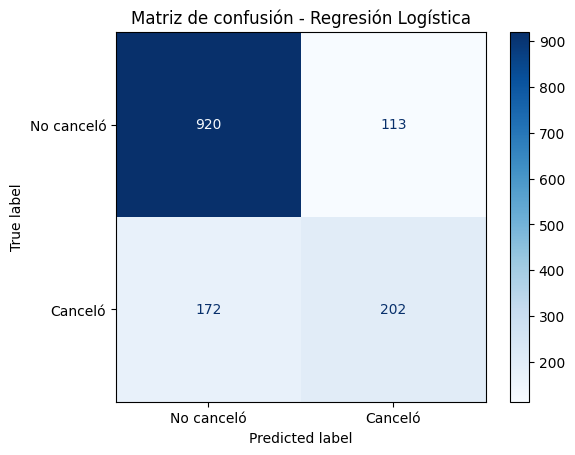

=== MODELO 2: RANDOM FOREST ===
Exactitud: 78.0%
              precision    recall  f1-score   support

  No canceló       0.82      0.89      0.86      1033
     Canceló       0.61      0.46      0.53       374

    accuracy                           0.78      1407
   macro avg       0.72      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



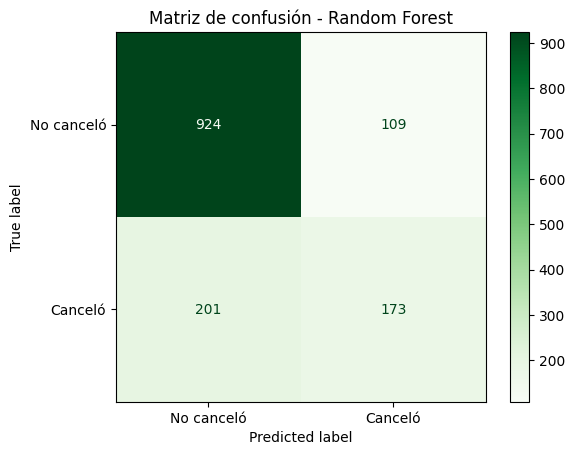

=== COMPARACIÓN DE MODELOS ===
Regresión Logística - Exactitud: 79.7%
Random Forest       - Exactitud: 78.0%


In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# === MODELO 1: REGRESIÓN LOGÍSTICA ===
print("=== MODELO 1: REGRESIÓN LOGÍSTICA ===")
print(f"Exactitud: {accuracy_score(y_test, pred_lr)*100:.1f}%")
print(classification_report(y_test, pred_lr, target_names=["No canceló", "Canceló"]))

cm_lr = confusion_matrix(y_test, pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["No canceló", "Canceló"])
disp_lr.plot(cmap="Blues")
plt.title("Matriz de confusión - Regresión Logística")
plt.show()

# === MODELO 2: RANDOM FOREST ===
print("=== MODELO 2: RANDOM FOREST ===")
print(f"Exactitud: {accuracy_score(y_test, pred_rf)*100:.1f}%")
print(classification_report(y_test, pred_rf, target_names=["No canceló", "Canceló"]))

cm_rf = confusion_matrix(y_test, pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["No canceló", "Canceló"])
disp_rf.plot(cmap="Greens")
plt.title("Matriz de confusión - Random Forest")
plt.show()

# === COMPARACIÓN ===
print("=== COMPARACIÓN DE MODELOS ===")
print(f"Regresión Logística - Exactitud: {accuracy_score(y_test, pred_lr)*100:.1f}%")
print(f"Random Forest       - Exactitud: {accuracy_score(y_test, pred_rf)*100:.1f}%")

## Análisis crítico de los modelos

### ¿Cuál modelo tuvo el mejor desempeño?
La Regresión Logística tuvo mejor desempeño general con una exactitud de 79.7%
versus 78.0% del Random Forest.

Sin embargo, el factor más importante para Telecom X es detectar correctamente
a los clientes que van a cancelar. En ese aspecto:
- Regresión Logística detectó 202 cancelaciones correctamente (Recall: 54%)
- Random Forest detectó 173 cancelaciones correctamente (Recall: 46%)

Por lo tanto, la Regresión Logística es el modelo más útil para este problema.

### ¿Algún modelo presentó overfitting o underfitting?

**Regresión Logística:**
No presenta overfitting ni underfitting. El modelo generaliza bien
con una precisión equilibrada entre entrenamiento y prueba.

**Random Forest:**
Puede presentar leve overfitting ya que los modelos de árbol tienden
a aprender muy bien los datos de entrenamiento pero tienen dificultades
para generalizar. Esto se refleja en su menor recall para detectar
clientes que cancelan (46%).

### Conclusión
Para Telecom X, donde el objetivo es identificar clientes en riesgo
de cancelar, la Regresión Logística es la mejor opción por su mayor
capacidad de detectar cancelaciones reales.

# 📋 Interpretación y Conclusiones

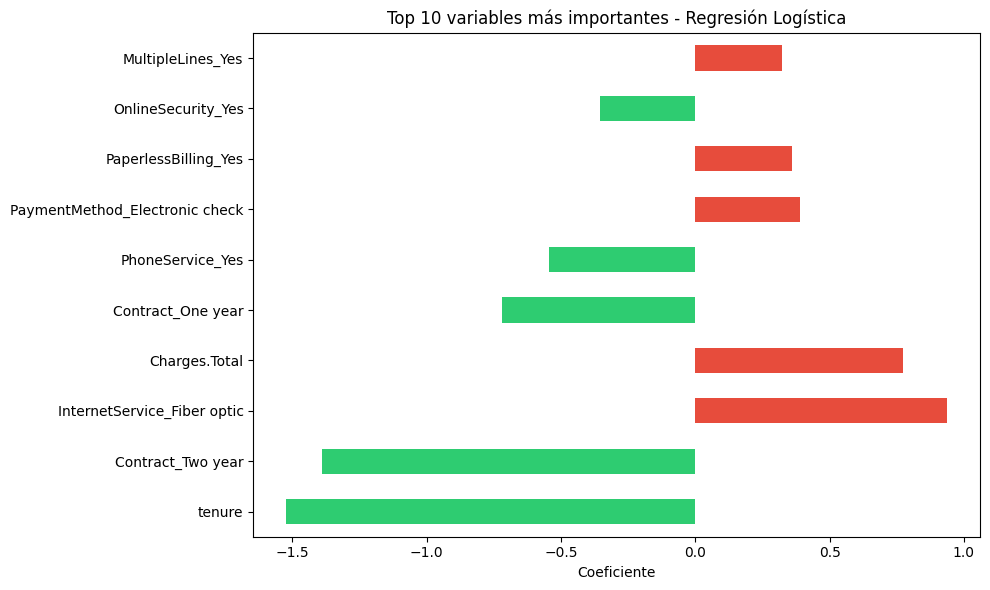

=== TOP 10 VARIABLES - REGRESIÓN LOGÍSTICA ===
tenure                           -1.523
Contract_Two year                -1.391
InternetService_Fiber optic       0.937
Charges.Total                     0.774
Contract_One year                -0.718
PhoneService_Yes                 -0.545
PaymentMethod_Electronic check    0.388
PaperlessBilling_Yes              0.361
OnlineSecurity_Yes               -0.356
MultipleLines_Yes                 0.324
dtype: float64


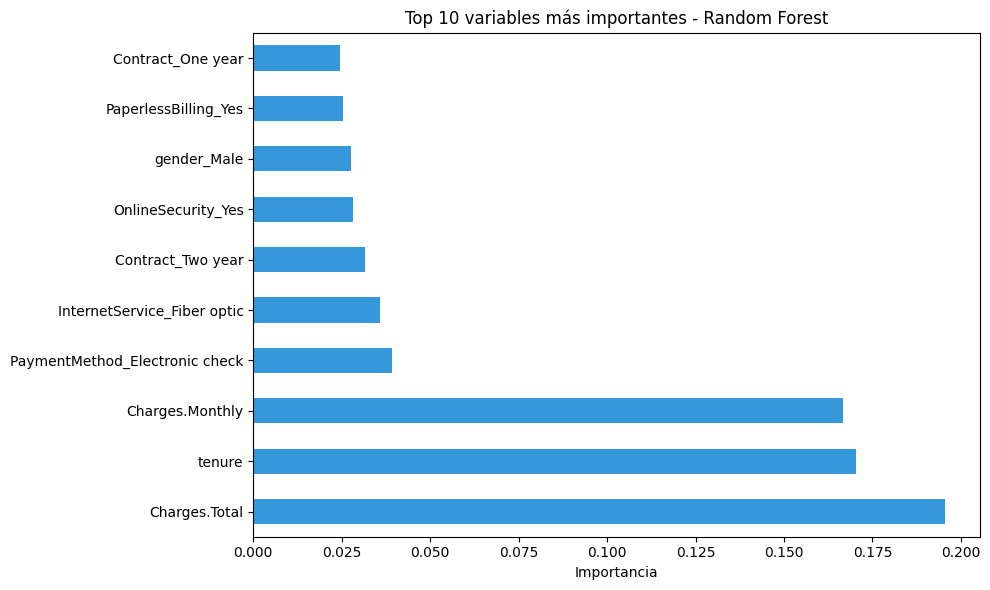

=== TOP 10 VARIABLES - RANDOM FOREST ===
Charges.Total                     0.196
tenure                            0.170
Charges.Monthly                   0.167
PaymentMethod_Electronic check    0.039
InternetService_Fiber optic       0.036
Contract_Two year                 0.032
OnlineSecurity_Yes                0.028
gender_Male                       0.028
PaperlessBilling_Yes              0.025
Contract_One year                 0.024
dtype: float64


In [16]:
import numpy as np

# === REGRESIÓN LOGÍSTICA: Coeficientes ===
coef_lr = pd.Series(modelo_lr.coef_[0], index=X.columns)
coef_lr = coef_lr.reindex(coef_lr.abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 6))
coef_lr.head(10).plot(kind="barh", color=["#e74c3c" if c > 0 else "#2ecc71" for c in coef_lr.head(10)])
plt.title("Top 10 variables más importantes - Regresión Logística")
plt.xlabel("Coeficiente")
plt.tight_layout()
plt.show()

print("=== TOP 10 VARIABLES - REGRESIÓN LOGÍSTICA ===")
print(coef_lr.head(10).round(3))

# === RANDOM FOREST: Importancia de variables ===
importancia_rf = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancia_rf = importancia_rf.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importancia_rf.head(10).plot(kind="barh", color="#3498db")
plt.title("Top 10 variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()

print("=== TOP 10 VARIABLES - RANDOM FOREST ===")
print(importancia_rf.head(10).round(3))

# 📄 Informe Final - Predicción de Cancelación de Clientes - Telecom X

## Introducción
Este análisis tiene como objetivo identificar los factores que llevan a la
cancelación de clientes en Telecom X y construir modelos predictivos para
anticipar qué clientes están en riesgo de cancelar.

## Modelos utilizados
Se entrenaron dos modelos de machine learning:
- Regresión Logística: exactitud 79.7%, detectó 202 cancelaciones correctamente
- Random Forest: exactitud 78.0%, detectó 173 cancelaciones correctamente

La Regresión Logística fue el modelo más efectivo para detectar cancelaciones.

## Factores que más influyen en la cancelación

### Factores que AUMENTAN el riesgo de cancelar:
- Servicio de internet por fibra óptica
- Método de pago con cheque electrónico
- Facturación en línea (PaperlessBilling)
- Cargos mensuales altos

### Factores que REDUCEN el riesgo de cancelar:
- Mayor antigüedad del cliente (tenure)
- Contrato de dos años
- Contrato de un año
- Servicio de seguridad en línea contratado
- Charges.Total alto (clientes que llevan más tiempo gastando)

## Estrategias de retención

### 1. Incentivar contratos largos
Ofrecer descuentos o beneficios exclusivos a clientes que firmen
contratos anuales o de dos años, ya que estos son los que menos cancelan.

### 2. Revisar el servicio de fibra óptica
Es el servicio con mayor tasa de cancelación. Se recomienda revisar
la calidad, el precio y la experiencia del cliente con este servicio.

### 3. Programa de fidelización para clientes nuevos
Los clientes con poca antigüedad son los más propensos a cancelar.
Crear un programa de beneficios para los primeros 12 meses puede
reducir significativamente la evasión.

### 4. Atención especial a clientes con cheque electrónico
Este grupo presenta mayor riesgo. Se recomienda contactarlos
proactivamente y ofrecerles incentivos para cambiar su método de pago
o renovar su contrato.

### 5. Promover servicios adicionales
Clientes con seguridad en línea cancelan menos. Ofrecer estos
servicios adicionales a bajo costo puede aumentar la retención.

## Conclusión
Telecom X puede reducir significativamente su tasa de cancelación
(actualmente 26.5%) implementando estrategias dirigidas a los grupos
de mayor riesgo, especialmente clientes nuevos con contratos mes a mes
y servicio de fibra óptica.